Import liberaries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

read in csv file and do sense checks

In [ ]:
df = pd.read_csv('Chocolate_Sales_2.csv')

In [ ]:
df

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184
...,...,...,...,...,...,...
3277,Karlen McCaffrey,Australia,Spicy Special Slims,17/05/2024,"$5,303.58",354
3278,Jehu Rudeforth,USA,White Choc,07/06/2024,"$7,339.32",121
3279,Ches Bonnell,Canada,Organic Choco Syrup,26/07/2024,$616.09,238
3280,Dotty Strutley,India,Eclairs,28/07/2024,"$2,504.62",397


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   3282 non-null   object
 1   Country        3282 non-null   object
 2   Product        3282 non-null   object
 3   Date           3282 non-null   object
 4   Amount         3282 non-null   object
 5   Boxes Shipped  3282 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 154.0+ KB


In [ ]:
df.isnull()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
3277,False,False,False,False,False,False
3278,False,False,False,False,False,False
3279,False,False,False,False,False,False
3280,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
Sales Person,0
Country,0
Product,0
Date,0
Amount,0
Boxes Shipped,0


In [ ]:
df.dtypes

,0
Sales Person,object
Country,object
Product,object
Date,object
Amount,object
Boxes Shipped,int64


In [ ]:
df.describe()

,Boxes Shipped
count,3282.000000
mean,164.666971
std,124.024736
min,1.000000
25%,71.000000
50%,137.000000
75%,232.000000
max,778.000000


data cleaning

In [ ]:
df['Date'] = pd.to_datetime(df['Date'],format='%d/%m/%Y')

In [ ]:
df.dtypes

,0
Sales Person,object
Country,object
Product,object
Date,datetime64[ns]
Amount,object
Boxes Shipped,int64


In [ ]:
df.Amount

,Amount
0,"$5,320.00"
1,"$7,896.00"
2,"$4,501.00"
3,"$12,726.00"
4,"$13,685.00"
...,...
3277,"$5,303.58"
3278,"$7,339.32"
3279,$616.09
3280,"$2,504.62"


In [ ]:
df['Amount'] = df['Amount'].str.replace('$','').str.replace(',','').astype('float')

In [ ]:
df.dtypes

,0
Sales Person,object
Country,object
Product,object
Date,datetime64[ns]
Amount,float64
Boxes Shipped,int64


In [ ]:
df.describe()

,Date,Amount,Boxes Shipped
count,3282,3282.000000,3282.000000
mean,2023-05-03 15:09:06.252284928,6030.338775,164.666971
min,2022-01-03 00:00:00,7.000000,1.000000
25%,2022-07-04 00:00:00,2521.495000,71.000000
50%,2023-05-11 00:00:00,5225.500000,137.000000
75%,2024-03-02 00:00:00,8556.842500,232.000000
max,2024-08-31 00:00:00,26170.950000,778.000000
std,NaN,4393.980200,124.024736


Exploratory data Alaysis

In [ ]:
# mean, median

In [ ]:
np.mean(df['Amount'])

np.float64(6030.338775137113)

In [ ]:
np.median(df['Boxes Shipped'])

np.float64(137.0)

In [ ]:
country_sale = df.groupby('Country')['Amount'].sum().sort_values(ascending=False)

In [ ]:
country_sale

,Amount
Country,
Australia,3646444.35
UK,3365388.90
India,3343730.83
USA,3313858.09
Canada,3078495.65
New Zealand,3043654.04


In [ ]:
country_sale.map('{:,.2f}'.format)

,Amount
Country,
Australia,"3,646,444.35"
UK,"3,365,388.90"
India,"3,343,730.83"
USA,"3,313,858.09"
Canada,"3,078,495.65"
New Zealand,"3,043,654.04"


In [ ]:
# top products by total sales
top_products = df.groupby('Product')['Amount'].sum().sort_values(ascending=False)

In [ ]:
top_products

,Amount
Product,
Smooth Sliky Salty,1120201.09
50% Dark Bites,1087659.35
White Choc,1054257.00
Peanut Butter Cubes,1036591.09
Eclairs,996947.96
99% Dark & Pure,960033.45
85% Dark Bars,955268.24
Organic Choco Syrup,945345.73
Spicy Special Slims,938131.69


In [ ]:
top_products.map('${:,.2f}'.format)

,Amount
Product,
Smooth Sliky Salty,"$1,120,201.09"
50% Dark Bites,"$1,087,659.35"
White Choc,"$1,054,257.00"
Peanut Butter Cubes,"$1,036,591.09"
Eclairs,"$996,947.96"
99% Dark & Pure,"$960,033.45"
85% Dark Bars,"$955,268.24"
Organic Choco Syrup,"$945,345.73"
Spicy Special Slims,"$938,131.69"


matplotlib

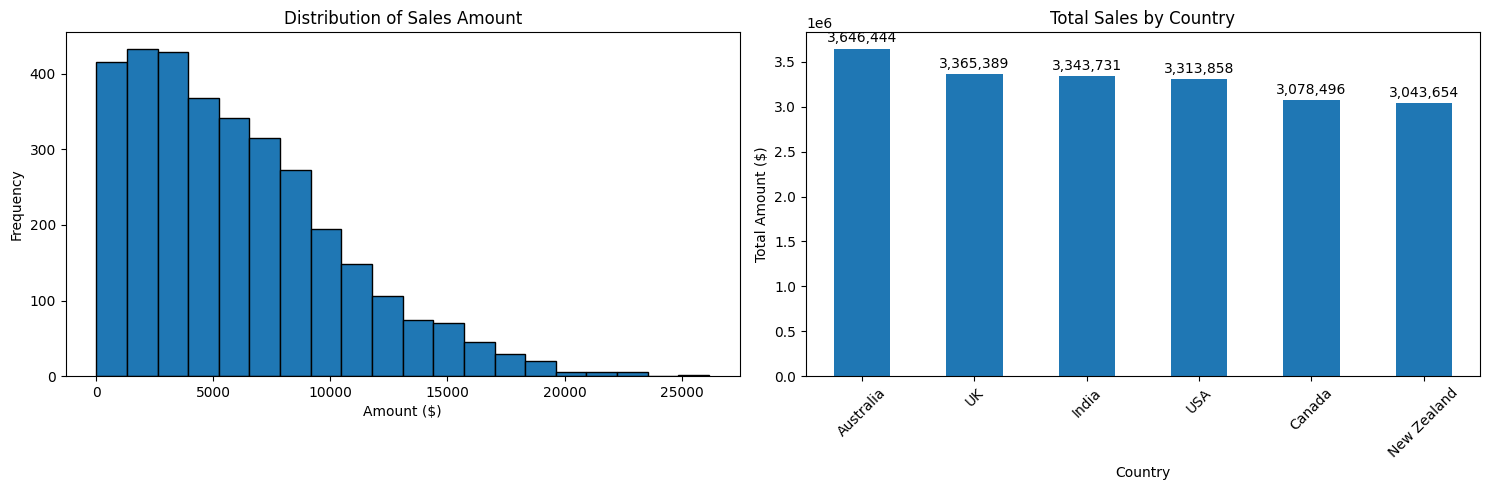

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.hist(df['Amount'], bins=20, edgecolor='black')
plt.title('Distribution of Sales Amount')
plt.xlabel('Amount ($)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
bars = country_sale.plot(kind='bar', ax=plt.gca())  # Get current axes
plt.title('Total Sales by Country')
plt.xlabel('Country')
plt.ylabel('Total Amount ($)')
plt.xticks(rotation=45)

# Add data labels only to bar chart
for i, v in enumerate(country_sale):
    plt.text(i, v + v*0.01, '{:,.0f}'.format(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

seaborn

/tmp/ipykernel_3971/3246287857.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  countplot = sns.barplot(x=amount_sum.values, y=amount_sum.index, ax=axs[1], palette="rocket")


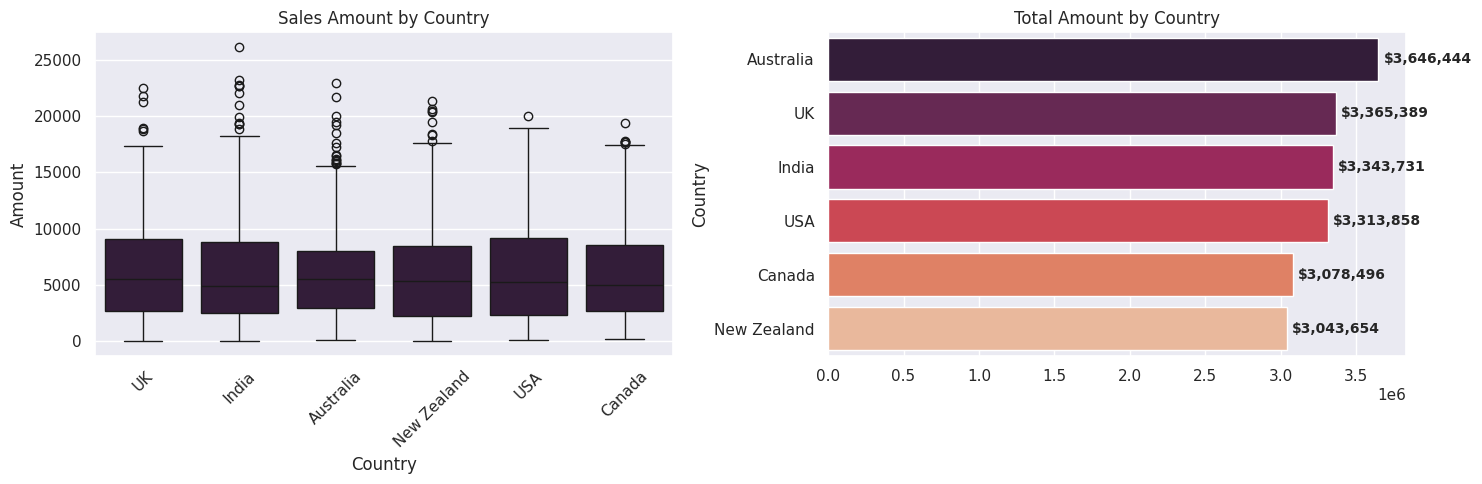

In [ ]:
sns.set_theme(
    style="darkgrid",
    palette="rocket",
)

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df, x='Country', y='Amount', ax=axs[0])
axs[0].set_title('Sales Amount by Country')
axs[0].tick_params(axis='x', rotation=45)

# Total Amount per Country
amount_sum = df.groupby('Country')['Amount'].sum().sort_values(ascending=False)
countplot = sns.barplot(x=amount_sum.values, y=amount_sum.index, ax=axs[1], palette="rocket")
axs[1].set_title('Total Amount by Country')

# Label bars with formatted currency
for p in countplot.patches:
    width = p.get_width()
    axs[1].text(width + width*0.01, p.get_y() + p.get_height()/2., f'${width:,.0f}',
                va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
top_products

,Amount
Product,
Smooth Sliky Salty,1120201.09
50% Dark Bites,1087659.35
White Choc,1054257.00
Peanut Butter Cubes,1036591.09
Eclairs,996947.96
99% Dark & Pure,960033.45
85% Dark Bars,955268.24
Organic Choco Syrup,945345.73
Spicy Special Slims,938131.69
